# Explainability with SHAP

In this notebook I explains the selected advanced model from Notebook 08 using SHAP.

The selected champion model is **Random Forest** because it achieved the strongest overall validation performance among the advanced models.

The goal is to understand which features drive predicted credit risk and how individual applicant predictions can be explained.

## 1. Environment Setup

Load the required libraries, connect to the project source code, and check that SHAP is available.

In [18]:
import json
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

try:
    import shap
except ImportError:
    shap = None

project_root = Path.cwd().resolve().parents[0]
src_dir = project_root / "src"

if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))

from credit_risk_platform.data.german_credit import interim_german_credit_dir
from credit_risk_platform.utils.io import load_csv

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", context="talk")

print("project_root:", project_root)
print("SHAP available:", shap is not None)

project_root: /Users/ememakpan/Documents/New project/applied_ai_economics_portfolio/project_01_ai_credit_risk_platform
SHAP available: True


## 2. Load the Standardized Dataset


In [19]:
interim_dir = interim_german_credit_dir(project_root)
df = load_csv(interim_dir / "german_credit_standardized.csv")

print("Shape:", df.shape)
df.head()

Shape: (1000, 24)


,applicant_id,checking_account_status,duration_months,credit_history,purpose,credit_amount,savings_account,employment_duration,installment_rate_pct_income,personal_status_sex,...,other_installment_plans,housing,existing_credits_count,job_type,liable_people_count,telephone,foreign_worker,risk_class,risk_label,TARGET
0,1,A11,6,A34,A43,1169,A65,A75,4,A93,...,A143,A152,2,A173,1,A192,A201,1,good,0
1,2,A12,48,A32,A43,5951,A61,A73,2,A92,...,A143,A152,1,A173,1,A191,A201,2,bad,1
2,3,A14,12,A34,A46,2096,A61,A74,2,A93,...,A143,A152,1,A172,2,A191,A201,1,good,0
3,4,A11,42,A32,A42,7882,A61,A74,2,A93,...,A143,A153,1,A173,2,A191,A201,1,good,0
4,5,A11,24,A33,A40,4870,A61,A73,3,A93,...,A143,A153,2,A173,2,A191,A201,2,bad,1


## 3. Define Features and Target

I needed to exclude the applicant identifier (Id's) and target-derived columns from the model features.

In [20]:
target_col = "TARGET"
identifier_cols = ["applicant_id"]
target_label_cols = ["risk_class", "risk_label"]
exclude_from_features = identifier_cols + target_label_cols + [target_col]

feature_cols = [col for col in df.columns if col not in exclude_from_features]
X = df[feature_cols].copy()
y = df[target_col].copy()

print("Feature count:", len(feature_cols))
display(pd.DataFrame({"feature_cols": pd.Series(feature_cols)}))

Feature count: 20


,feature_cols
0,checking_account_status
1,duration_months
2,credit_history
3,purpose
4,credit_amount
5,savings_account
6,employment_duration
7,installment_rate_pct_income
8,personal_status_sex
9,other_debtors_guarantors


## 4. Recreate the Validation Split

I refer to stratified split as Notebook 08 so model performance and explanation with same validation sample.

In [21]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y,
)

X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=y_temp,
)

print("Train:", X_train.shape)
print("Validation:", X_valid.shape)
print("Test:", X_test.shape)

Train: (700, 20)
Validation: (150, 20)
Test: (150, 20)


## 5. Rebuild the Random Forest Champion Pipeline

Tree-based models do not require scaling. The pipeline uses imputation and one-hot encoding, then fits the selected Random Forest model.

In [22]:
numeric_features = X_train.select_dtypes(include="number").columns.tolist()
categorical_features = X_train.select_dtypes(exclude="number").columns.tolist()

try:
    one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", one_hot_encoder),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numeric_features),
        ("categorical", categorical_transformer, categorical_features),
    ]
)

champion_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                min_samples_leaf=5,
                class_weight="balanced",
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        ),
    ]
)

champion_pipeline.fit(X_train, y_train)
champion_pipeline

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numeric', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## 6. Champion Model Performance

Just to ensure the Random Forest model matches the validation behavior from Notebook 08.

In [23]:
y_valid_pred = champion_pipeline.predict(X_valid)
y_valid_score = champion_pipeline.predict_proba(X_valid)[:, 1]

print(classification_report(y_valid, y_valid_pred, target_names=["low_risk", "high_risk"]))
print("ROC-AUC:", round(roc_auc_score(y_valid, y_valid_score), 4))
print("PR-AUC:", round(average_precision_score(y_valid, y_valid_score), 4))

              precision    recall  f1-score   support

    low_risk       0.83      0.74      0.78       105
   high_risk       0.52      0.64      0.57        45

    accuracy                           0.71       150
   macro avg       0.67      0.69      0.68       150
weighted avg       0.74      0.71      0.72       150

ROC-AUC: 0.7873
PR-AUC: 0.6113


## 7. Prepare Processed Validation Data for SHAP

SHAP explains the fitted Random Forest model after preprocessing. This means categorical variables have already been converted into one-hot encoded numeric features.

In [24]:
fitted_preprocessor = champion_pipeline.named_steps["preprocessor"]
fitted_model = champion_pipeline.named_steps["model"]

X_valid_processed = fitted_preprocessor.transform(X_valid)
processed_feature_names = fitted_preprocessor.get_feature_names_out()

X_valid_processed_df = pd.DataFrame(
    X_valid_processed,
    columns=processed_feature_names,
    index=X_valid.index,
)

print("Processed validation shape:", X_valid_processed_df.shape)
X_valid_processed_df.head()

Processed validation shape: (150, 61)


,numeric__duration_months,numeric__credit_amount,numeric__installment_rate_pct_income,numeric__present_residence_years,numeric__age_years,numeric__existing_credits_count,numeric__liable_people_count,categorical__checking_account_status_A11,categorical__checking_account_status_A12,categorical__checking_account_status_A13,...,categorical__housing_A152,categorical__housing_A153,categorical__job_type_A171,categorical__job_type_A172,categorical__job_type_A173,categorical__job_type_A174,categorical__telephone_A191,categorical__telephone_A192,categorical__foreign_worker_A201,categorical__foreign_worker_A202
309,9.0,276.0,4.0,4.0,22.0,1.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
404,18.0,2899.0,4.0,4.0,43.0,1.0,2.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
940,12.0,3527.0,2.0,3.0,45.0,1.0,2.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
832,45.0,11816.0,2.0,4.0,29.0,2.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
575,15.0,2788.0,2.0,3.0,24.0,2.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0


## 8. Calculate SHAP Values

SHAP explains how each feature pushes a prediction toward low risk or high risk. 

In [25]:

explainer = shap.TreeExplainer(fitted_model)
shap_values = explainer.shap_values(X_valid_processed_df)

if isinstance(shap_values, list):
    shap_values_high_risk = shap_values[1]
else:
    shap_values_high_risk = shap_values[:, :, 1] if getattr(shap_values, "ndim", 2) == 3 else shap_values

print("SHAP values shape:", shap_values_high_risk.shape)

SHAP values shape: (150, 61)


## 9. Global SHAP Feature Importance

Global feature importance shows which features have the largest average impact on the model's high-risk predictions.

In [26]:
shap_importance = pd.DataFrame(
    {
        "feature": processed_feature_names,
        "mean_abs_shap": abs(shap_values_high_risk).mean(axis=0),
    }
).sort_values("mean_abs_shap", ascending=False)

top_shap_features = shap_importance.head(20)
top_shap_features

,feature,mean_abs_shap
10,categorical__checking_account_status_A14,0.073263
7,categorical__checking_account_status_A11,0.036832
0,numeric__duration_months,0.036688
26,categorical__savings_account_A61,0.028421
15,categorical__credit_history_A34,0.024395
1,numeric__credit_amount,0.021304
49,categorical__other_installment_plans_A143,0.016192
4,numeric__age_years,0.015374
30,categorical__savings_account_A65,0.014915
51,categorical__housing_A152,0.014264


## 10. Plot Top SHAP Risk Drivers

So using SHAP the bar chart will summarizes the strongest model drivers for predicted high credit risk.

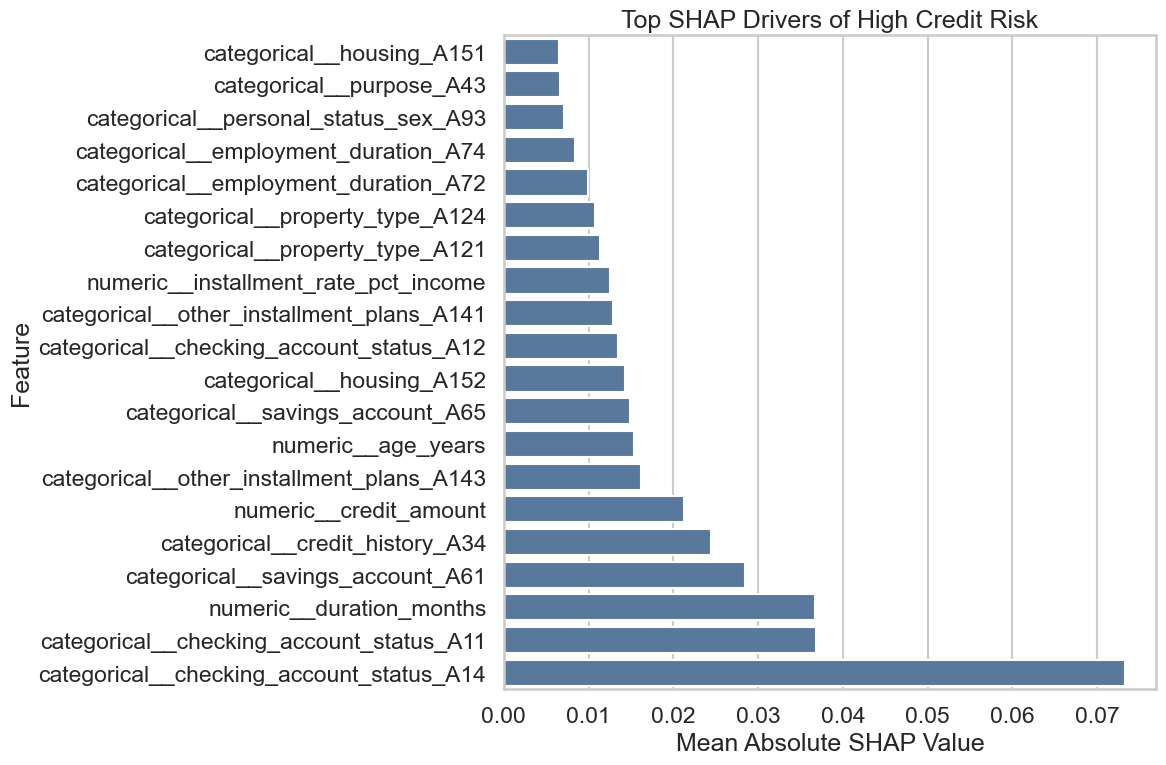

In [27]:
plt.figure(figsize=(12, 8))
sns.barplot(
    data=top_shap_features.sort_values("mean_abs_shap", ascending=True),
    x="mean_abs_shap",
    y="feature",
    color="#4c78a8",
)
plt.title("Top SHAP Drivers of High Credit Risk")
plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

-The above bar shows checking account status is the strongest signal in the model. In the German Credit dataset, A14 usually means no checking account. The model found this category very influential for credit-risk prediction.

## 11. SHAP Summary Plot

The SHAP summary plot shows both feature importance and whether high or low feature values push the model toward high-risk predictions.

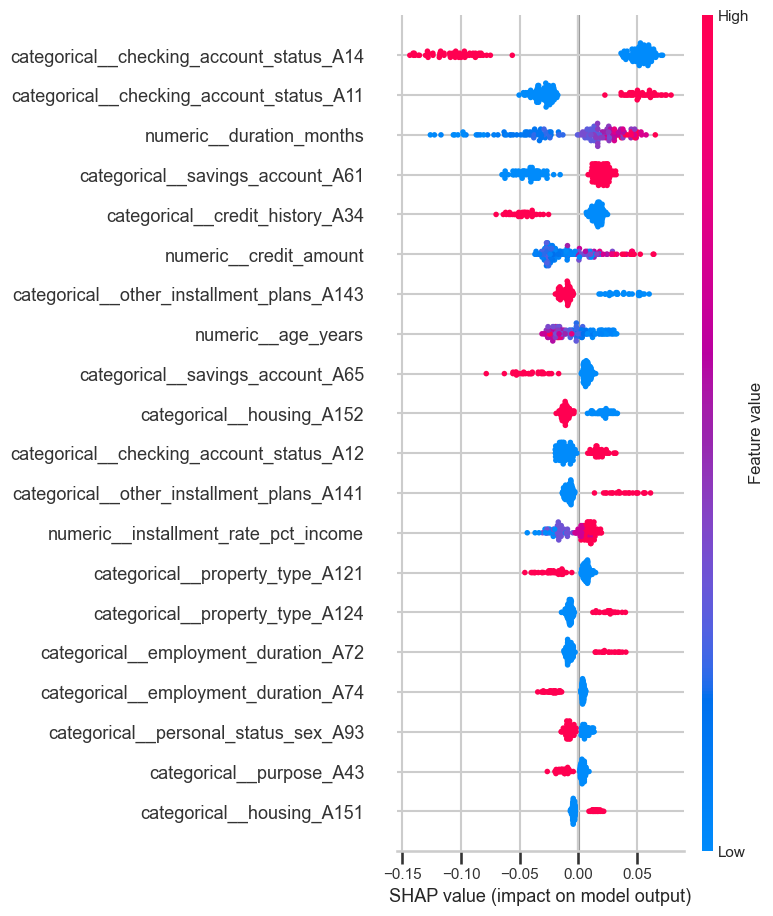

In [28]:
shap.summary_plot(
    shap_values_high_risk,
    X_valid_processed_df,
    max_display=20,
    show=True,
)

- ### SHAP Summary Plot Interpretation

The SHAP summary plot shows both the importance and direction of each feature's impact on the Random Forest model.

The strongest driver is checking account status. `checking_account_status_A14` tends to push predictions away from high risk, while `checking_account_status_A11` pushes predictions toward high risk. This suggests that the model treats different checking account categories as very different risk signals.

Longer loan duration generally increases predicted high-risk probability. Savings account category A61 also pushes predictions toward higher risk, while credit history category `A34` pushes predictions toward lower risk.

Overall, the SHAP results are consistent with credit-risk reasoning: account status, loan duration, savings position, credit history, and credit amount are key drivers of predicted default risk.


## 12. Explain One Applicant Prediction

I validated applicant with a high predicted risk score and show which features contributed most to that prediction.

In [29]:
highest_risk_position = int(pd.Series(y_valid_score, index=X_valid.index).sort_values(ascending=False).index[0])
highest_risk_row_position = list(X_valid.index).index(highest_risk_position)

applicant_original = X_valid.loc[[highest_risk_position]].T.rename(columns={highest_risk_position: "value"})
predicted_probability = float(y_valid_score[highest_risk_row_position])
actual_target = int(y_valid.loc[highest_risk_position])

print("Applicant index:", highest_risk_position)
print("Predicted high-risk probability:", round(predicted_probability, 4))
print("Actual target:", actual_target)
display(applicant_original)

Applicant index: 522
Predicted high-risk probability: 0.7914
Actual target: 1


,value
checking_account_status,A11
duration_months,48
credit_history,A30
purpose,A42
credit_amount,7119
savings_account,A61
employment_duration,A73
installment_rate_pct_income,3
personal_status_sex,A93
other_debtors_guarantors,A101


- Applicant index: 522
Predicted high-risk probability: 79.14%
Actual target: 1


## 13. Local SHAP Contribution Table

This table shows the strongest features pushing this applicant toward or away from a high-risk prediction.

In [30]:
local_shap = pd.DataFrame(
    {
        "feature": processed_feature_names,
        "processed_value": X_valid_processed_df.iloc[highest_risk_row_position].values,
        "shap_value_high_risk": shap_values_high_risk[highest_risk_row_position],
    }
)

local_shap["abs_shap"] = local_shap["shap_value_high_risk"].abs()
local_shap.sort_values("abs_shap", ascending=False).head(15)

,feature,processed_value,shap_value_high_risk,abs_shap
10,categorical__checking_account_status_A14,0.0,0.057466,0.057466
7,categorical__checking_account_status_A11,1.0,0.050267,0.050267
0,numeric__duration_months,48.0,0.049428,0.049428
46,categorical__property_type_A124,1.0,0.031304,0.031304
26,categorical__savings_account_A61,1.0,0.026339,0.026339
15,categorical__credit_history_A34,0.0,0.023400,0.023400
51,categorical__housing_A152,0.0,0.021042,0.021042
11,categorical__credit_history_A30,1.0,0.015764,0.015764
1,numeric__credit_amount,7119.0,0.011813,0.011813
30,categorical__savings_account_A65,0.0,0.011770,0.011770


## 14. Save Explainability Artifacts

Save the champion model pipeline and SHAP summary tables for later reporting and deployment work.

In [31]:
models_dir = project_root / "models"
tables_dir = project_root / "artifacts" / "tables"
profiles_dir = project_root / "artifacts" / "profiles"

models_dir.mkdir(parents=True, exist_ok=True)
tables_dir.mkdir(parents=True, exist_ok=True)
profiles_dir.mkdir(parents=True, exist_ok=True)

champion_model_path = models_dir / "random_forest_champion_pipeline.joblib"
shap_importance_path = tables_dir / "shap_global_feature_importance.csv"
local_shap_path = tables_dir / "shap_local_high_risk_applicant.csv"
summary_path = profiles_dir / "shap_explainability_summary.json"

joblib.dump(champion_pipeline, champion_model_path)
shap_importance.to_csv(shap_importance_path, index=False)
local_shap.sort_values("abs_shap", ascending=False).to_csv(local_shap_path, index=False)

explainability_summary = {
    "champion_model": "random_forest",
    "model_path": str(champion_model_path.relative_to(project_root)),
    "top_10_global_features": top_shap_features.head(10).to_dict(orient="records"),
    "local_applicant_index": highest_risk_position,
    "local_applicant_predicted_high_risk_probability": round(predicted_probability, 4),
    "local_applicant_actual_target": actual_target,
}

with summary_path.open("w") as f:
    json.dump(explainability_summary, f, indent=2)

champion_model_path, shap_importance_path, local_shap_path, summary_path

(PosixPath('/Users/ememakpan/Documents/New project/applied_ai_economics_portfolio/project_01_ai_credit_risk_platform/models/random_forest_champion_pipeline.joblib'),
 PosixPath('/Users/ememakpan/Documents/New project/applied_ai_economics_portfolio/project_01_ai_credit_risk_platform/artifacts/tables/shap_global_feature_importance.csv'),
 PosixPath('/Users/ememakpan/Documents/New project/applied_ai_economics_portfolio/project_01_ai_credit_risk_platform/artifacts/tables/shap_local_high_risk_applicant.csv'),
 PosixPath('/Users/ememakpan/Documents/New project/applied_ai_economics_portfolio/project_01_ai_credit_risk_platform/artifacts/profiles/shap_explainability_summary.json'))

## 15. Explainability Decision Summary

SHAP helps translate the Random Forest model from a black-box prediction system into a more explainable credit-risk tool.

The global SHAP results identify the strongest overall drivers of predicted high credit risk. The local SHAP table shows how the model explains one applicant-level prediction.
